# Experiment 05 — Finite-length simulation validation (Figure 4)

This notebook reads the CSV generated by `experiment/05_finite_length_simulation_validation.py` and produces a publication-style Figure 4.

**Visualization improvements**
- 1×4 facet layout (weak / auc≈0.7 / auc≈0.8 / auc≈0.9)
- Benchmark (App. A) is the main theory (thick solid)
- Weak-screening theory (Eq. 6/8) as contrast (thin dashed)
- Upper bound (Thm. 6 ∧ finite-pool) in grey (dash-dot)
- Finite-pool oracle in light grey (dotted)
- Single shared legend (deduplicated)


Saved SciencePlots figure: /home/leiyo/GitHub/Attention-Constrained-Leaderless-Inference/result/figure/05_finite_length_simulation_validation_facets.pdf


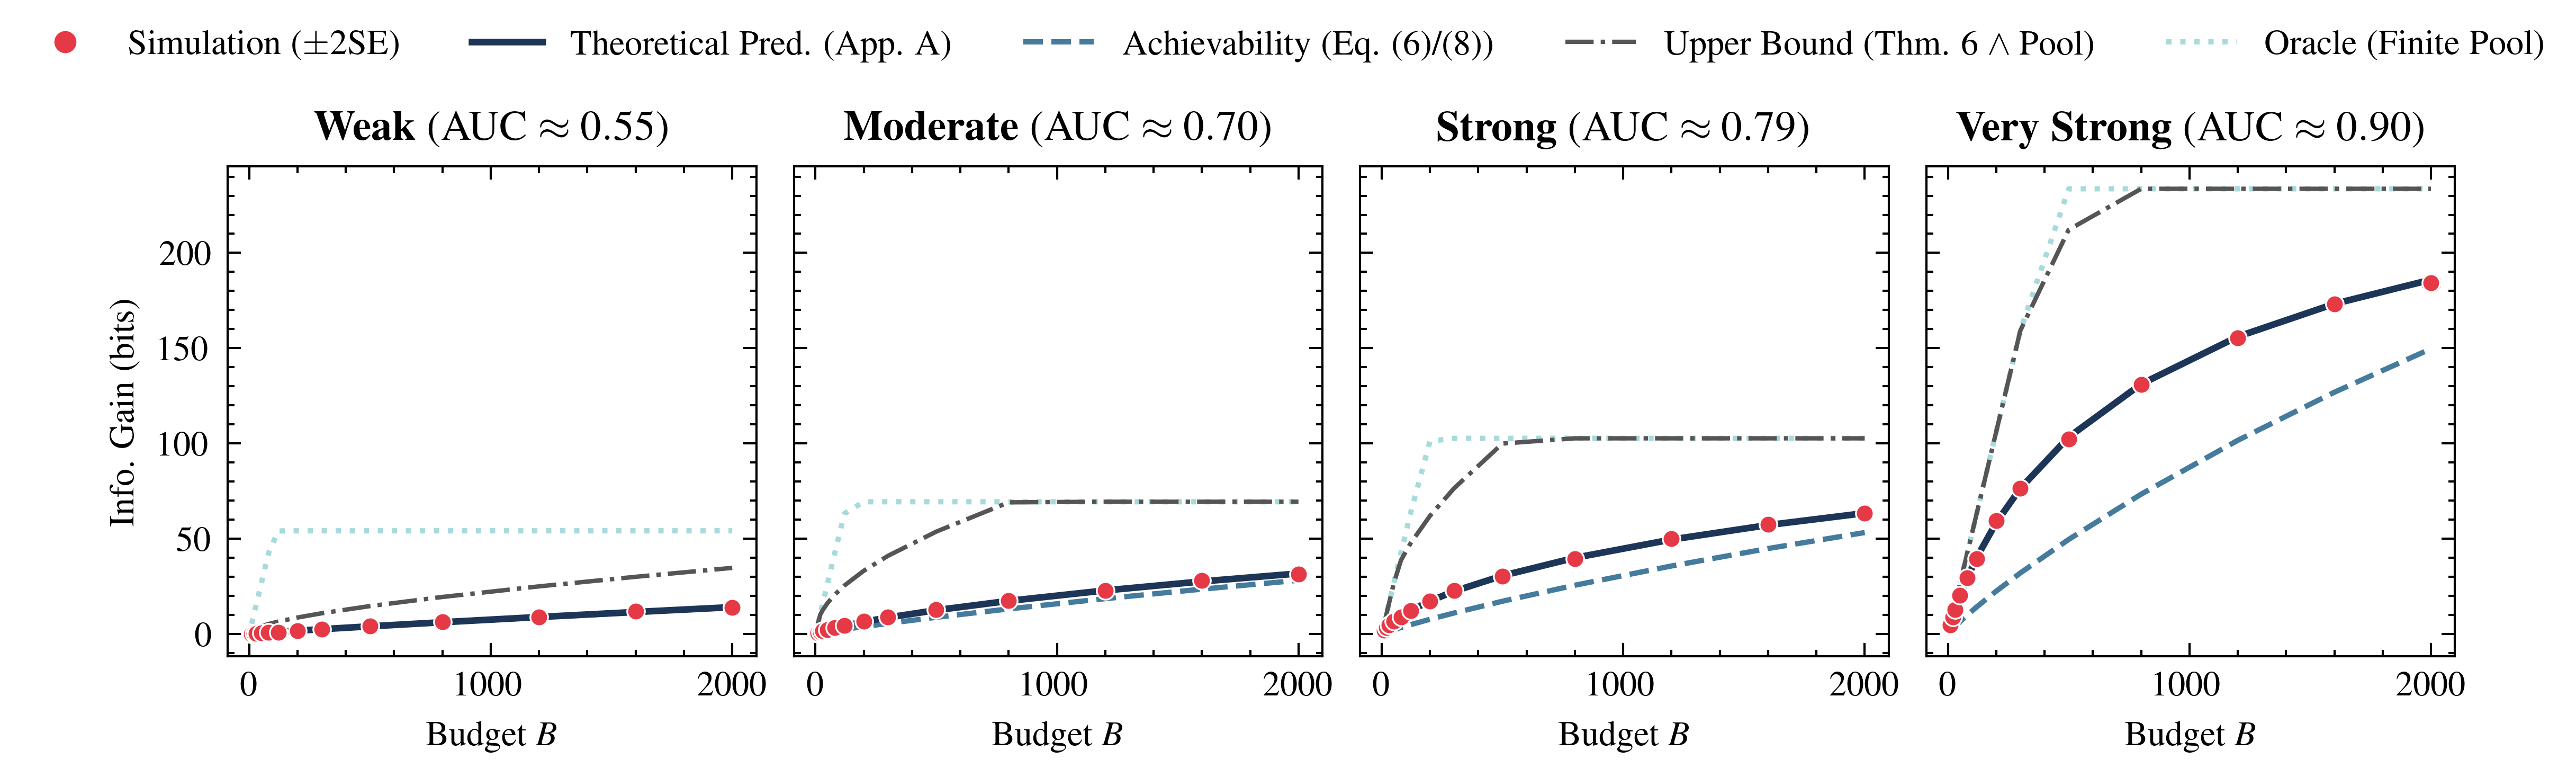

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import scienceplots  


plt.style.use(['science', 'ieee'])


STYLES = {
    "simulation": {
        "label": r"Simulation ($\pm 2$SE)",
        "color": "#E63946",  
        "marker": "o",
        "linestyle": "None",
        "markersize": 4,    
        "markeredgecolor": "white",
        "markeredgewidth": 0.4,
        "zorder": 10
    },
    "benchmark": {
        "label": r"Theoretical Pred. (App. A)",
        "color": "#1D3557",  
        "linestyle": "-",
        "linewidth": 1.5,    
        "zorder": 5
    },
    "weak_theory": {
        "label": r"Achievability (Eq. (6)/(8))",
        "color": "#457B9D",  
        "linestyle": "--",
        "linewidth": 1.2,
        "zorder": 4
    },
    "upper_bound": {
        "label": r"Upper Bound (Thm. 6 $\wedge$ Pool)",
        "color": "#555555",  # 灰
        "linestyle": "-.",
        "linewidth": 1.0,
        "zorder": 3
    },
    "oracle": {
        "label": r"Oracle (Finite Pool)",
        "color": "#A8DADC",  
        "linestyle": ":",
        "linewidth": 1.2,
        "zorder": 2
    }
}

def plot_fancy_charts():
    ROOT = Path('..').resolve()
    csv_path = ROOT / 'result' / 'table' / '05_finite_length_simulation_validation.csv'
    fig_path = ROOT / 'result' / 'figure' / '05_finite_length_simulation_validation_facets.pdf'

    if not csv_path.exists():
        print(f"File not found: {csv_path}")
        return

    df = pd.read_csv(csv_path)

    scenario_order = ['weak', 'auc~0.7', 'auc~0.8', 'auc~0.9']
    present = [s for s in scenario_order if s in df['scenario'].unique()]
    if not present:
        present = list(df["scenario"].unique())

    titles = {
        "weak": r"\textbf{Weak} (AUC $\approx 0.55$)",
        "auc~0.7": r"\textbf{Moderate} (AUC $\approx 0.70$)",
        "auc~0.8": r"\textbf{Strong} (AUC $\approx 0.79$)",
        "auc~0.9": r"\textbf{Very Strong} (AUC $\approx 0.90$)",
    }

    # Meta parameters
    K = int(df["K"].iloc[0])
    delta = float(df["delta"].iloc[0])
    p0 = float(df["p0"].iloc[0])
    I_ver = float(df["I_ver_bits"].iloc[0])


    fig, axes = plt.subplots(
        1, len(present), 
        figsize=(7.5, 2.1),  
        sharex=True, sharey=True,
        constrained_layout=True
    )

    if len(present) == 1:
        axes = [axes]

    for ax, sc in zip(axes, present):
        d = df[df["scenario"] == sc].sort_values("B")
        B = d["B"].to_numpy()

        if "oracle_pool_gain_bits" in d.columns:
            s = STYLES["oracle"]
            ax.plot(B, d["oracle_pool_gain_bits"], **{k:v for k,v in s.items() if k != 'label'})

        col_upper = "upper_thm6_pool_gain_bits" if "upper_thm6_pool_gain_bits" in d.columns else "theorem6_upper_gain_bits"
        s = STYLES["upper_bound"]
        ax.plot(B, d[col_upper], **{k:v for k,v in s.items() if k != 'label'})

        s = STYLES["weak_theory"]
        ax.plot(B, d["theory_gain_bits"], **{k:v for k,v in s.items() if k != 'label'})

        if "benchmark_gain_bits" in d.columns:
            s = STYLES["benchmark"]
            ax.plot(B, d["benchmark_gain_bits"], **{k:v for k,v in s.items() if k != 'label'})

        s = STYLES["simulation"]
        ax.errorbar(
            B, 
            d["sim_gain_bits"], 
            yerr=2 * d["sim_gain_bits_se"],
            fmt=s["marker"],
            color=s["color"],
            markersize=s["markersize"],
            markeredgecolor=s["markeredgecolor"],
            markeredgewidth=s["markeredgewidth"],
            elinewidth=1.0, 
            capsize=2,
            zorder=s["zorder"]
        )
        
        ax.set_title(titles.get(sc, sc))
        ax.set_xlabel(r"Budget $B$") 

    axes[0].set_ylabel(r"Info. Gain (bits)")

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=STYLES["simulation"]["color"], marker=STYLES["simulation"]["marker"], 
               linestyle='None', label=STYLES["simulation"]["label"], 
               markerfacecolor=STYLES["simulation"]["color"], markeredgecolor='white'),
        Line2D([0], [0], color=STYLES["benchmark"]["color"], lw=STYLES["benchmark"]["linewidth"], 
               label=STYLES["benchmark"]["label"]),
        Line2D([0], [0], color=STYLES["weak_theory"]["color"], lw=STYLES["weak_theory"]["linewidth"], 
               linestyle=STYLES["weak_theory"]["linestyle"], label=STYLES["weak_theory"]["label"]),
        Line2D([0], [0], color=STYLES["upper_bound"]["color"], lw=STYLES["upper_bound"]["linewidth"], 
               linestyle=STYLES["upper_bound"]["linestyle"], label=STYLES["upper_bound"]["label"]),
        Line2D([0], [0], color=STYLES["oracle"]["color"], lw=STYLES["oracle"]["linewidth"], 
               linestyle=STYLES["oracle"]["linestyle"], label=STYLES["oracle"]["label"]),
    ]


    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15), 
        ncol=5,
        frameon=False,
        fontsize=8 
    )


    fig_path.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(fig_path, format="pdf", bbox_inches='tight')
    print("Saved SciencePlots figure:", fig_path)

if __name__ == "__main__":
    plot_fancy_charts()